N_PANELS: 26
saved plot


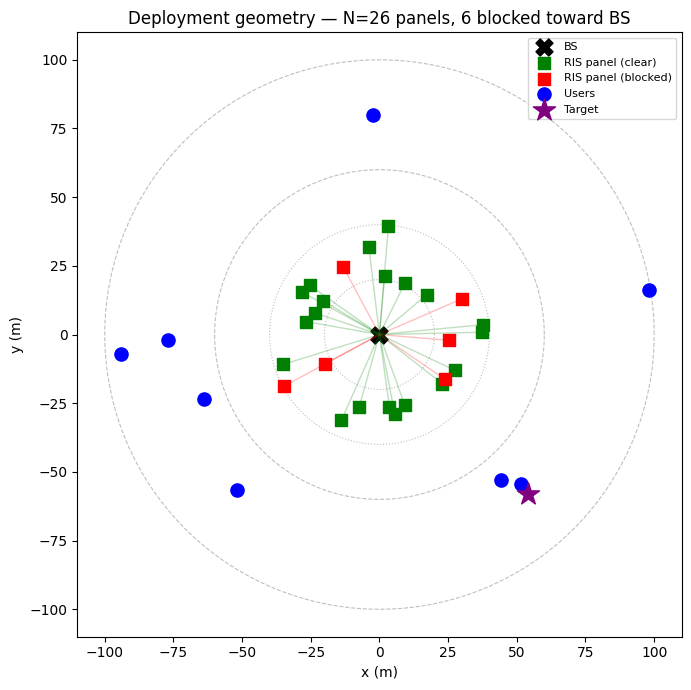

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def to_linear(db):
    return 10 ** (db / 10.0)

def sample_polar(radius_range, angle_range, rng):
    r = rng.uniform(*radius_range)
    theta = rng.uniform(*angle_range)
    return np.array([r * np.cos(theta), r * np.sin(theta)])

def bearing(from_pos, to_pos):
    d = to_pos - from_pos
    return np.arctan2(d[1], d[0])

def distance(from_pos, to_pos):
    return np.linalg.norm(to_pos - from_pos)

# ---------------- occlusion: distance-dependent probability ----------------
def occlusion_probability(d, d0=60.0, scale=20.0, p_max=0.6):
    """Logistic blockage probability: rises with distance, capped at p_max."""
    return p_max / (1 + np.exp(-(d - d0) / scale))

def is_blocked(d, rng, **kwargs):
    return rng.random() < occlusion_probability(d, **kwargs)

def get_link_params(blocked, kappa_los_db=5.0, eta_los=2.5, eta_nlos=3.5):
    """Occlusion decides which (kappa, eta) an individual link instance uses --
    same hybrid channel function as before, just fed different parameters."""
    if blocked:
        return 0.0, eta_nlos
    return to_linear(kappa_los_db), eta_los

# ---------------- config ----------------
BS_POS = np.array([0.0, 0.0])
PANEL_RADIUS = (20.0, 40.0)
USER_RADIUS = (60.0, 100.0)
TARGET_RADIUS = (60.0, 100.0)
K_USERS = 8

rng = np.random.default_rng(seed=50)

# ---------------- random panel count, 10-30 inclusive ----------------
N_PANELS = rng.integers(10, 31)
print("N_PANELS:", N_PANELS)

# ---------------- sample positions ----------------
panel_pos = [sample_polar(PANEL_RADIUS, (0, 2 * np.pi), rng) for _ in range(N_PANELS)]
panel_boresight = [bearing(p, BS_POS) for p in panel_pos]

user_pos = [sample_polar(USER_RADIUS, (0, 2 * np.pi), rng) for _ in range(K_USERS)]
target_pos = sample_polar(TARGET_RADIUS, (0, 2 * np.pi), rng)

# ---------------- occlusion for each panel<->BS link ----------------
panel_blocked = []
for i in range(N_PANELS):
    d = distance(BS_POS, panel_pos[i])
    blocked = is_blocked(d, rng)
    panel_blocked.append(blocked)
    kappa_g, eta_g = get_link_params(blocked)
    # kappa_g, eta_g now feed straight into get_Gi(...) exactly as before --
    # nothing about the channel function itself changes.
panel_blocked = np.array(panel_blocked)

# ---------------- plot ----------------
fig, ax = plt.subplots(figsize=(7, 7))

theta = np.linspace(0, 2 * np.pi, 200)
for r in PANEL_RADIUS:
    ax.plot(r * np.cos(theta), r * np.sin(theta), ':', color='gray', linewidth=0.8, alpha=0.5)
for r in USER_RADIUS:
    ax.plot(r * np.cos(theta), r * np.sin(theta), '--', color='gray', linewidth=0.8, alpha=0.5)

ax.scatter(*BS_POS, marker='X', s=150, color='black', label='BS')

panel_arr = np.array(panel_pos)
clear_mask = ~panel_blocked
ax.scatter(panel_arr[clear_mask, 0], panel_arr[clear_mask, 1], marker='s', s=70,
           color='green', label='RIS panel (clear)', zorder=4)
ax.scatter(panel_arr[panel_blocked, 0], panel_arr[panel_blocked, 1], marker='s', s=70,
           color='red', label='RIS panel (blocked)', zorder=4)

for i in range(N_PANELS):
    color = 'red' if panel_blocked[i] else 'green'
    ax.plot([BS_POS[0], panel_pos[i][0]], [BS_POS[1], panel_pos[i][1]],
            color=color, alpha=0.25, linewidth=1)

user_arr = np.array(user_pos)
ax.scatter(user_arr[:, 0], user_arr[:, 1], marker='o', s=90, color='blue', label='Users', zorder=4)

ax.scatter(*target_pos, marker='*', s=280, color='purple', label='Target', zorder=4)

ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title(f"Deployment geometry — N={N_PANELS} panels, {panel_blocked.sum()} blocked toward BS")
ax.legend(loc='upper right', fontsize=8)
ax.set_aspect('equal')
plt.tight_layout()
print("saved plot")

[array([-35.0246497 , -10.87249765]),
 array([ 3.26143511, 39.33400024]),
 array([30.22728706, 13.08639433]),
 array([-25.43787822,  17.91209167]),
 array([25.23072553, -2.1161874 ]),
 array([-13.22507896,  24.61901607]),
 array([17.20685557, 14.50225578]),
 array([-34.90853417, -18.88933237]),
 array([37.67210953,  3.58021224]),
 array([-28.05819093,  15.3737524 ]),
 array([ -7.41466403, -26.4551956 ]),
 array([ 1.89019889, 21.14384099]),
 array([-23.62769225,   7.90580783]),
 array([  3.62774748, -26.38522823]),
 array([  5.59630467, -28.9254615 ]),
 array([-19.79366208, -10.6928774 ]),
 array([-13.84255938, -31.20243156]),
 array([ 9.19390913, 18.58486853]),
 array([-3.87248161, 31.94707361]),
 array([ 22.85713706, -17.89606681]),
 array([37.24126781,  0.83817253]),
 array([ 27.35699584, -12.9818329 ]),
 array([-26.58334239,   4.68384231]),
 array([  9.25550703, -25.79246161]),
 array([ 23.77539448, -16.23906512]),
 array([-20.45860355,  12.19856567])]